In [1]:
import os
os.chdir("..")
%pwd

'/Users/beamaia/Documents/ndb_ufes_data_organizer'

In [2]:
import pandas as pd

In [9]:
train_raw_data = pd.read_csv("data/ndb_ufes/uncontaminated_train_folds.csv")
test_raw_data = pd.read_csv("data/ndb_ufes/uncontaminated_test_fold.csv")

In [26]:
train_binary_oscc_not_oscc = train_raw_data.copy()
train_binary_oscc_displasia = train_raw_data.copy()
train_binary_displasia = train_raw_data.copy()

test_binary_oscc_not_oscc = test_raw_data.copy()
test_binary_oscc_displasia = test_raw_data.copy()
test_binary_displasia = test_raw_data.copy()

In [27]:
train_binary_oscc_not_oscc.head()

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,diagnosis,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold
0,p0029,12,12,101,14,0012.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1423.0,-520.0,1935.0,1032.0,1
1,p0030,12,12,101,14,0012.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1488.0,-820.0,2000.0,1332.0,1
2,p0036,12,12,101,14,0012.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1483.0,-263.0,1995.0,775.0,1
3,p0048,12,12,101,14,0012.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1218.0,-12.0,1730.0,524.0,1
4,p2835,12,12,101,14,0012.png,Floor of mouth,3.0,Yes,Former,...,OSCC,NaN,OSCC,Presence,OSCC,1532.0,-223.0,2044.0,735.0,1


In [28]:
train_binary_oscc_not_oscc["class"] = train_raw_data["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
train_binary_oscc_not_oscc.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
1183,p0636,136,136,85,79,0136.png,Tongue,3.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,1027.0,-883.0,1539.0,1395.0,3,1
2346,p1791,62,62,104,60,0062.png,Tongue,0.1,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,994.0,-759.0,1506.0,1271.0,5,1
179,p0833,215,215,37,35,0215.png,Palate,0.3,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,34.0,-580.0,546.0,1092.0,1,0
288,p2228,131,131,47,45,0131.png,Buccal mucosa,1.5,Yes,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1075.0,-439.0,1587.0,951.0,1,0
997,p3685,213,213,98,92,0213.png,Floor of mouth,0.0,Yes,No,...,NaN,OSCC,Presence,OSCC,652.0,-852.0,1164.0,1364.0,2,1
291,p2231,131,131,47,45,0131.png,Buccal mucosa,1.5,Yes,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,628.0,-289.0,1140.0,801.0,1,0
861,p1872,71,71,73,67,0071.png,Gingiva,1.5,Yes,No,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,987.0,-969.0,1499.0,1481.0,2,0
405,p2031,92,92,78,72,0092.png,Gingiva,4.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,552.0,-579.0,1064.0,1091.0,1,0
554,p0192,20,20,11,10,0020.png,Palate,1.5,Former,No,...,NaN,OSCC,Presence,OSCC,501.0,-486.0,1013.0,998.0,2,1
1468,p3452,39,39,96,90,0039.png,Buccal mucosa,0.2,Yes,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1439.0,-158.0,1951.0,670.0,3,0


In [29]:
test_binary_oscc_not_oscc["class"] = test_raw_data["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
test_binary_oscc_not_oscc.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
334,p1670,51,51,130,82,0051.png,Buccal mucosa,4.5,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,962.0,-148.0,1474.0,660.0,6,0
399,p2156,107,107,95,89,0107.png,Gingiva,0.0,No,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,189.0,-513.0,701.0,1025.0,6,0
229,p1143,130,130,47,45,0130.png,Buccal mucosa,1.5,Yes,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,243.0,-670.0,755.0,1182.0,6,0
437,p2715,198,198,70,65,0198.png,Buccal mucosa,1.5,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1271.0,-473.0,1783.0,985.0,6,0
290,p1390,8,8,103,78,0008.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,32.0,-97.0,544.0,609.0,6,0
177,p0915,37,37,96,90,0037.png,Buccal mucosa,0.2,Yes,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,962.0,-1002.0,1474.0,1514.0,6,0
135,p0687,176,176,89,83,0176.png,Floor of mouth,0.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,1171.0,-902.0,1683.0,1414.0,6,1
125,p2605,178,178,89,83,0178.png,Floor of mouth,0.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,148.0,-383.0,660.0,895.0,6,1
197,p1640,46,46,53,51,0046.png,Lip,1.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,856.0,-546.0,1368.0,1058.0,6,0
316,p1412,9,9,103,78,0009.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,87.0,-542.0,599.0,1054.0,6,0


In [36]:
train_binary_oscc_displasia = train_binary_oscc_displasia[train_binary_oscc_displasia["diagnosis"] != "Leukoplakia without dysplasia"]
test_binary_oscc_displasia = test_binary_oscc_displasia[test_binary_oscc_displasia["diagnosis"] != "Leukoplakia without dysplasia"]

train_binary_oscc_displasia["class"] = train_binary_oscc_displasia["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)
test_binary_oscc_displasia["class"] = test_binary_oscc_displasia["diagnosis"].apply(lambda x: 1 if x == "OSCC" else 0)

train_binary_oscc_displasia.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
564,p0258,34,34,33,31,0034.png,Tongue,1.0,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,803.0,-693.0,1315.0,1205.0,2,1
1098,p0362,74,74,31,28,0074.png,Floor of mouth,3.5,Yes,Former,...,NaN,OSCC,Presence,OSCC,678.0,-654.0,1190.0,1166.0,3,1
356,p1586,33,33,102,31,0033.png,Tongue,1.2,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,109.0,-946.0,621.0,1458.0,1,1
1319,p3321,55,55,15,13,0055.png,Buccal mucosa,0.0,Yes,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,198.0,-580.0,710.0,1092.0,3,0
1249,p0783,209,209,20,18,0209.png,Gingiva,3.0,Former,Former,...,NaN,OSCC,Presence,OSCC,922.0,-453.0,1434.0,965.0,3,1
2093,p2251,79,79,42,40,0079.png,Tongue,1.0,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,1278.0,-278.0,1790.0,790.0,5,0
692,p0863,43,43,106,78,0043.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,727.0,-575.0,1239.0,1087.0,2,0
65,p0285,156,156,90,84,0156.png,Tongue,0.4,Not informed,Not informed,...,NaN,OSCC,Presence,OSCC,1466.0,-132.0,1978.0,644.0,1,1
1735,p1128,120,120,1,1,0120.png,Gingiva,1.0,Not informed,Not informed,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1497.0,-135.0,2009.0,647.0,4,0
1461,p1630,39,39,96,90,0039.png,Buccal mucosa,0.2,Yes,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,320.0,-31.0,832.0,543.0,3,0


In [37]:
train_binary_displasia = train_binary_displasia[train_binary_displasia["diagnosis"] != "OSCC"]
test_binary_displasia = test_binary_displasia[test_binary_displasia["diagnosis"] != "OSCC"]

train_binary_displasia["class"] = train_binary_displasia["diagnosis"].apply(lambda x: 1 if x == "Leukoplakia with dysplasia" else 0)
test_binary_displasia["class"] = test_binary_displasia["diagnosis"].apply(lambda x: 1 if x == "Leukoplakia with dysplasia" else 0)

train_binary_displasia.sample(15)

,patch,origin,public_id,lesion_id,patient_id,path,localization,larger_size,tobacco_use,alcohol_consumption,...,dysplasia_severity,TaskII,TaskIII,TaskIV,top_left_x,top_left_y,bottom_right_x,bottom_right_y,fold,class
404,p2030,92,92,78,72,0092.png,Gingiva,4.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,1167.0,-446.0,1679.0,958.0,1,0
1749,p1145,126,126,47,45,0126.png,Buccal mucosa,1.5,Yes,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,332.0,-710.0,844.0,1222.0,4,1
1283,p3297,216,216,37,35,0216.png,Palate,0.3,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,635.0,-805.0,1147.0,1317.0,3,1
1889,p2021,94,94,78,72,0094.png,Gingiva,4.5,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,154.0,-205.0,666.0,717.0,4,0
829,p3401,199,199,75,69,0199.png,Buccal mucosa,2.0,Not informed,Not informed,...,NaN,Leukoplakia,Absence,Leukoplakia without dysplasia,1425.0,-975.0,1937.0,1487.0,2,0
471,p1430,41,41,84,78,0041.png,Tongue,0.4,No,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1088.0,-840.0,1600.0,1352.0,2,1
313,p1340,190,190,57,54,0190.png,Lip,1.5,Yes,Former,...,Moderate,Leukoplakia,Presence,Leukoplakia with dysplasia,406.0,-737.0,918.0,1249.0,1,1
286,p2226,131,131,47,45,0131.png,Buccal mucosa,1.5,Yes,No,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,1282.0,-957.0,1794.0,1469.0,1,1
2400,p2398,163,163,32,30,0163.png,Tongue,3.0,Yes,Yes,...,Mild,Leukoplakia,Presence,Leukoplakia with dysplasia,817.0,-933.0,1329.0,1445.0,5,1
640,p3074,78,78,42,40,0078.png,Tongue,1.0,Not informed,Not informed,...,Severe,Leukoplakia,Presence,Leukoplakia with dysplasia,394.0,-186.0,906.0,698.0,2,1


In [39]:
import matplotlib.pyplot as plt
import numpy as np

In [50]:
folds_train_binary_oscc_not_oscc = train_binary_oscc_not_oscc[["fold", "class"]]
folds_test_binary_oscc_not_oscc = test_binary_oscc_not_oscc[["fold", "class"]]
folds_train_binary_oscc_displasia = train_binary_oscc_displasia[["fold", "class"]]
folds_test_binary_oscc_displasia = test_binary_oscc_displasia[["fold", "class"]]
folds_train_binary_displasia = train_binary_displasia[["fold", "class"]]
folds_test_binary_displasia = test_binary_displasia[["fold", "class"]]

In [55]:
folds_train_binary_oscc_not_oscc_1 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 1].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_2 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 2].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_3 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 3].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_4 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 4].value_counts(normalize=True))
folds_train_binary_oscc_not_oscc_5 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 5].value_counts(normalize=True))
folds_test_binary_oscc_not_oscc_6 = pd.DataFrame(folds_test_binary_oscc_not_oscc[folds_test_binary_oscc_not_oscc["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_oscc_not_oscc = pd.concat([folds_train_binary_oscc_not_oscc_1,
                                                    folds_train_binary_oscc_not_oscc_2,
                                                    folds_train_binary_oscc_not_oscc_3,
                                                    folds_train_binary_oscc_not_oscc_4,
                                                    folds_train_binary_oscc_not_oscc_5,
                                                    folds_test_binary_oscc_not_oscc_6])
prop_folds_train_binary_oscc_not_oscc

proportion
fold class            
1    0        0.506579
     1        0.493421
2    0        0.529304
     1        0.470696
3    1        0.557915
     0        0.442085
4    0        0.520243
     1        0.479757
5    1        0.526432
     0        0.473568
6    0        0.543710
     1        0.456290

In [56]:
folds_train_binary_oscc_displasia_1 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 1].value_counts(normalize=True))
folds_train_binary_oscc_displasia_2 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 2].value_counts(normalize=True))
folds_train_binary_oscc_displasia_3 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 3].value_counts(normalize=True))
folds_train_binary_oscc_displasia_4 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 4].value_counts(normalize=True))
folds_train_binary_oscc_displasia_5 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 5].value_counts(normalize=True))
folds_test_binary_oscc_displasia_6 = pd.DataFrame(folds_test_binary_oscc_displasia[folds_test_binary_oscc_displasia["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_oscc_displasia = pd.concat([folds_train_binary_oscc_displasia_1,
                                                    folds_train_binary_oscc_displasia_2,
                                                    folds_train_binary_oscc_displasia_3,
                                                    folds_train_binary_oscc_displasia_4,
                                                    folds_train_binary_oscc_displasia_5,
                                                    folds_test_binary_oscc_displasia_6])
prop_folds_train_binary_oscc_displasia

proportion
fold class            
1    1        0.637394
     0        0.362606
2    1        0.616307
     0        0.383693
3    1        0.655329
     0        0.344671
4    1        0.622047
     0        0.377953
5    1        0.645946
     0        0.354054
6    1        0.558747
     0        0.441253

In [57]:
folds_train_binary_displasia_1 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 1].value_counts(normalize=True))
folds_train_binary_displasia_2 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 2].value_counts(normalize=True))
folds_train_binary_displasia_3 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 3].value_counts(normalize=True))
folds_train_binary_displasia_4 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 4].value_counts(normalize=True))
folds_train_binary_displasia_5 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 5].value_counts(normalize=True))
folds_test_binary_displasia_6 = pd.DataFrame(folds_test_binary_displasia[folds_test_binary_displasia["fold"] == 6].value_counts(normalize=True))

prop_folds_train_binary_displasia = pd.concat([folds_train_binary_displasia_1,
                                                    folds_train_binary_displasia_2,
                                                    folds_train_binary_displasia_3,
                                                    folds_train_binary_displasia_4,
                                                    folds_train_binary_displasia_5,
                                                    folds_test_binary_displasia_6])
prop_folds_train_binary_displasia

proportion
fold class            
1    1        0.554113
     0        0.445887
2    1        0.553633
     0        0.446367
3    1        0.663755
     0        0.336245
4    1        0.560311
     0        0.439689
5    1        0.609302
     0        0.390698
6    1        0.662745
     0        0.337255

In [81]:
plt.rcParams["figure.figsize"] = 18,5

def create_folds_prop(diagnosis_names, df, ax, title):
    folds_per = {
        '1': round(df.query("fold == 1")["proportion"] * 100,2), 
        '2': round(df.query("fold == 2")["proportion"] * 100,2),
        '3': round(df.query("fold == 3")["proportion"] * 100,2),
        '4': round(df.query("fold == 4")["proportion"] * 100,2),
        '5': round(df.query("fold == 5")["proportion"] * 100,2),
        '6': round(df.query("fold == 6")["proportion"] * 100,2)
    }

    x = np.arange(len(diagnosis_names))  # the label locations
    width = 0.15 # the width of the bars
    multiplier = 0

    for attribute, measurement in folds_per.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, align='edge')
        ax.bar_label(rects, padding=5)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Percentage')
    ax.set_title(title)
    ax.set_xticks(x + width + 0.3, diagnosis_names)
    ax.legend(loc='upper left', ncols=6)
    ax.set_ylim(0, 100)


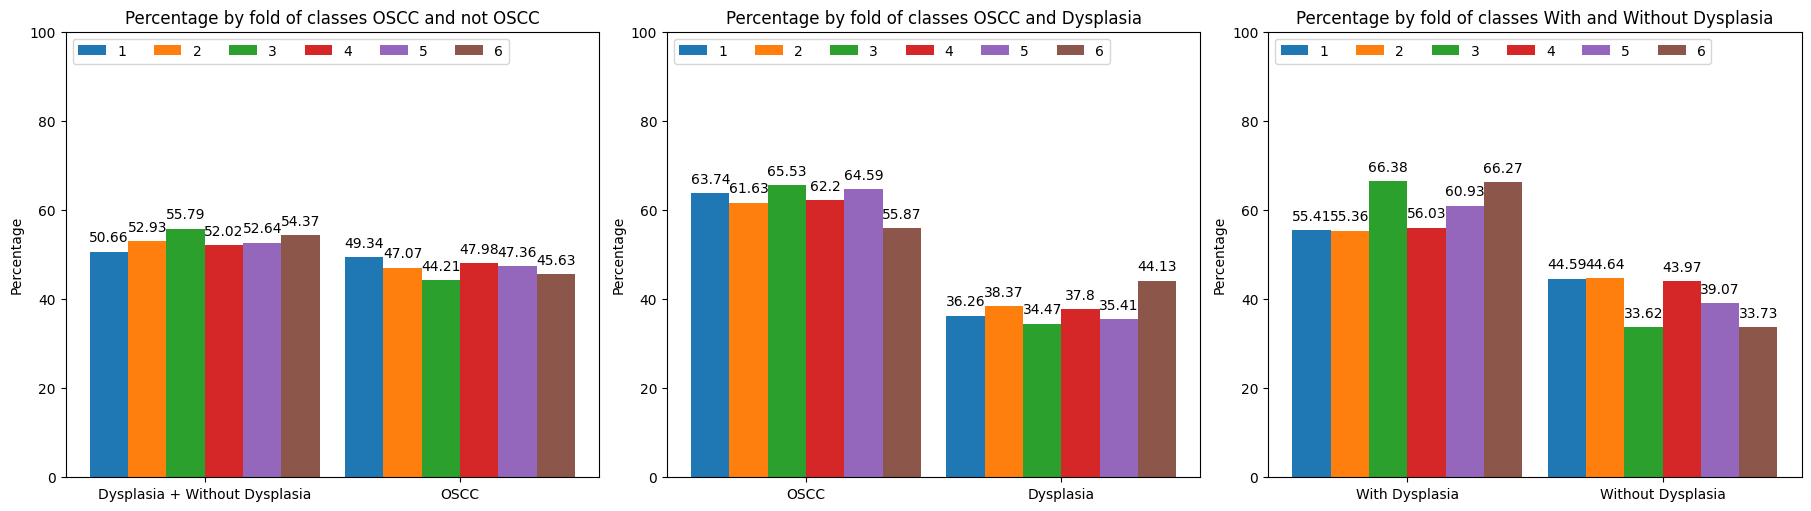

In [87]:
fig, ax = plt.subplots(1, 3, layout='constrained')

diagnosis_names = ["Dysplasia + Without Dysplasia", "OSCC"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_not_oscc, ax[0], "Percentage by fold of classes OSCC and not OSCC")

diagnosis_names = ["OSCC", "Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_displasia, ax[1], "Percentage by fold of classes OSCC and Dysplasia")

diagnosis_names = ["With Dysplasia", "Without Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_displasia, ax[2], "Percentage by fold of classes With and Without Dysplasia")

In [88]:
folds_train_binary_oscc_displasia_1 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 1].value_counts(normalize=False))
folds_train_binary_oscc_displasia_2 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 2].value_counts(normalize=False))
folds_train_binary_oscc_displasia_3 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 3].value_counts(normalize=False))
folds_train_binary_oscc_displasia_4 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 4].value_counts(normalize=False))
folds_train_binary_oscc_displasia_5 = pd.DataFrame(folds_train_binary_oscc_displasia[folds_train_binary_oscc_displasia["fold"] == 5].value_counts(normalize=False))
folds_test_binary_oscc_displasia_6 = pd.DataFrame(folds_test_binary_oscc_displasia[folds_test_binary_oscc_displasia["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_oscc_displasia = pd.concat([folds_train_binary_oscc_displasia_1,
                                                    folds_train_binary_oscc_displasia_2,
                                                    folds_train_binary_oscc_displasia_3,
                                                    folds_train_binary_oscc_displasia_4,
                                                    folds_train_binary_oscc_displasia_5,
                                                    folds_test_binary_oscc_displasia_6])
num_folds_train_binary_oscc_displasia

count
fold class       
1    1        225
     0        128
2    1        257
     0        160
3    1        289
     0        152
4    1        237
     0        144
5    1        239
     0        131
6    1        214
     0        169

In [89]:
folds_train_binary_oscc_not_oscc_1 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 1].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_2 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 2].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_3 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 3].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_4 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 4].value_counts(normalize=False))
folds_train_binary_oscc_not_oscc_5 = pd.DataFrame(folds_train_binary_oscc_not_oscc[folds_train_binary_oscc_not_oscc["fold"] == 5].value_counts(normalize=False))
folds_test_binary_oscc_not_oscc_6 = pd.DataFrame(folds_test_binary_oscc_not_oscc[folds_test_binary_oscc_not_oscc["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_oscc_not_oscc = pd.concat([folds_train_binary_oscc_not_oscc_1,
                                                    folds_train_binary_oscc_not_oscc_2,
                                                    folds_train_binary_oscc_not_oscc_3,
                                                    folds_train_binary_oscc_not_oscc_4,
                                                    folds_train_binary_oscc_not_oscc_5,
                                                    folds_test_binary_oscc_not_oscc_6])
num_folds_train_binary_oscc_not_oscc

count
fold class       
1    0        231
     1        225
2    0        289
     1        257
3    1        289
     0        229
4    0        257
     1        237
5    1        239
     0        215
6    0        255
     1        214

In [90]:
folds_train_binary_displasia_1 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 1].value_counts(normalize=False))
folds_train_binary_displasia_2 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 2].value_counts(normalize=False))
folds_train_binary_displasia_3 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 3].value_counts(normalize=False))
folds_train_binary_displasia_4 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 4].value_counts(normalize=False))
folds_train_binary_displasia_5 = pd.DataFrame(folds_train_binary_displasia[folds_train_binary_displasia["fold"] == 5].value_counts(normalize=False))
folds_test_binary_displasia_6 = pd.DataFrame(folds_test_binary_displasia[folds_test_binary_displasia["fold"] == 6].value_counts(normalize=False))

num_folds_train_binary_displasia = pd.concat([folds_train_binary_displasia_1,
                                                    folds_train_binary_displasia_2,
                                                    folds_train_binary_displasia_3,
                                                    folds_train_binary_displasia_4,
                                                    folds_train_binary_displasia_5,
                                                    folds_test_binary_displasia_6])
num_folds_train_binary_displasia

count
fold class       
1    1        128
     0        103
2    1        160
     0        129
3    1        152
     0         77
4    1        144
     0        113
5    1        131
     0         84
6    1        169
     0         86

In [97]:
desc_bin_dysplasia = pd.concat([num_folds_train_binary_displasia, prop_folds_train_binary_displasia], axis=1).add_prefix("bin_dysplasia1_no_dysplasia0_", axis=1)
desc_bin_oscc_dysplasia = pd.concat([num_folds_train_binary_oscc_displasia, prop_folds_train_binary_oscc_displasia], axis=1).add_prefix("bin_oscc1_dysplasia0_", axis=1)
desc_bin_oscc_no_oscc = pd.concat([num_folds_train_binary_oscc_not_oscc, prop_folds_train_binary_oscc_not_oscc], axis=1).add_prefix("bin_oscc1_not_oscc0_", axis=1)

In [104]:
desc_folds = pd.concat([desc_bin_oscc_no_oscc, desc_bin_oscc_dysplasia, desc_bin_dysplasia], axis=1).sort_index()

In [105]:
import pathlib as pl

In [106]:
ndb_ufes_path = pl.Path("data/ndb_ufes")

In [107]:
train_binary_oscc_not_oscc.to_csv(ndb_ufes_path / "bin_oscc_not_oscc_folds_train.csv", index=False)
test_binary_oscc_not_oscc.to_csv(ndb_ufes_path / "bin_oscc_not_oscc_folds_test.csv", index=False)
train_binary_oscc_displasia.to_csv(ndb_ufes_path / "bin_oscc_dysplasia_folds_train.csv", index=False)
test_binary_oscc_displasia.to_csv(ndb_ufes_path / "bin_oscc_dysplasia_folds_test.csv", index=False)
train_binary_displasia.to_csv(ndb_ufes_path / "bin_dysplasia_no_dysplasia_folds_train.csv", index=False)
test_binary_displasia.to_csv(ndb_ufes_path / "bin_dysplasia_no_dysplasia_folds_test.csv", index=False)
desc_folds.to_csv(ndb_ufes_path / "description_binary_folds.csv")

In [110]:
os.makedirs(ndb_ufes_path / "artifacts")

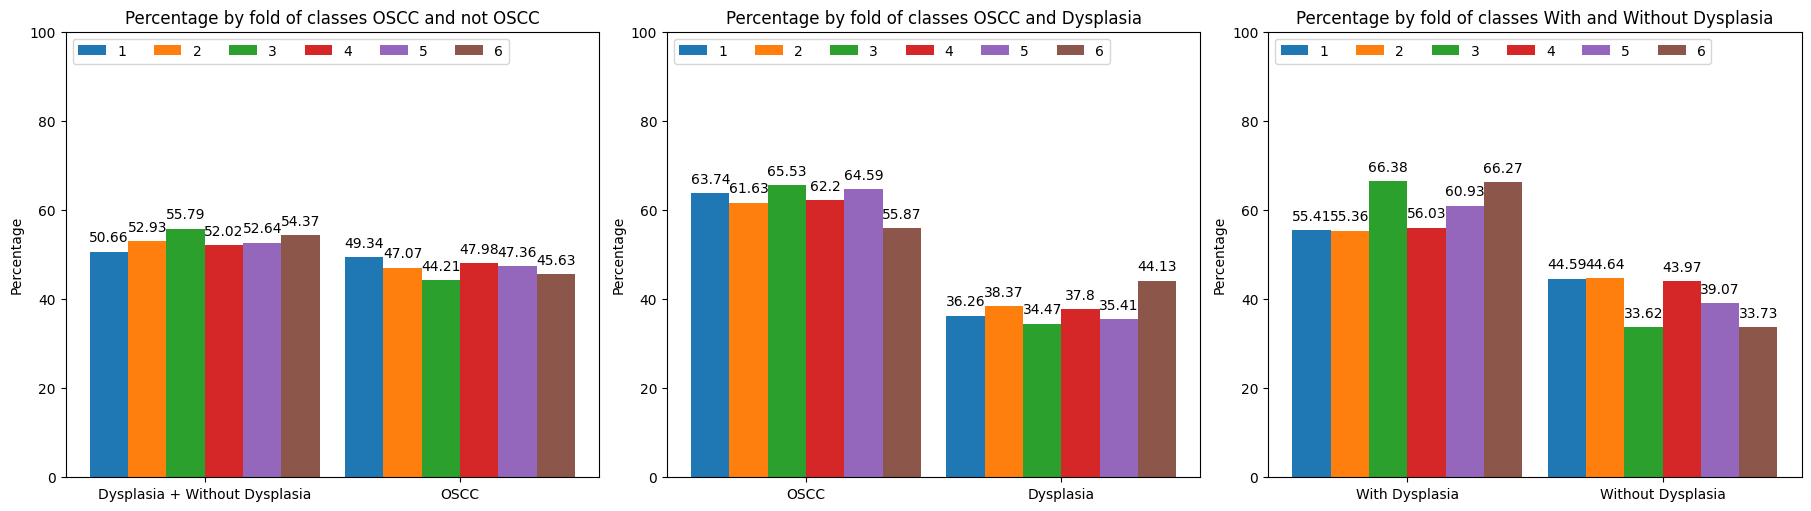

In [111]:
fig, ax = plt.subplots(1, 3, layout='constrained')

diagnosis_names = ["Dysplasia + Without Dysplasia", "OSCC"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_not_oscc, ax[0], "Percentage by fold of classes OSCC and not OSCC")

diagnosis_names = ["OSCC", "Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_oscc_displasia, ax[1], "Percentage by fold of classes OSCC and Dysplasia")

diagnosis_names = ["With Dysplasia", "Without Dysplasia"]
create_folds_prop(diagnosis_names, prop_folds_train_binary_displasia, ax[2], "Percentage by fold of classes With and Without Dysplasia")

plt.savefig(ndb_ufes_path / "artifacts" / "binary_folds_proportions.png")